# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Abdul-Samad-17/FlyRank-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Which content pages should be prioritized for refresh review, based on decline risk?

**Decision supported:** which pages a content reviewer checks first, given limited time.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** FlyRank/internship-warehouse (Hugging Face), `fact_content_daily_performance`, month=2026-03.

**Date window:** March 1-31, 2026. Features from days 1-15, label from days 16-31.

**Excluded:** any FlyRank product decision flag (health_score, priority_score) — not present in this release, deliberately excluded to avoid circularity.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os, duckdb, pandas as pd, numpy as np
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"""CREATE SECRET hf_token (TYPE huggingface, TOKEN '{os.environ["HF_TOKEN"]}');""")
BASE = "hf://datasets/FlyRank/internship-warehouse"

# Proof: grain check (no duplicates)
dupes = con.sql(f"""
    SELECT report_date, client_hash_id, content_hash_id, COUNT(*) as n
    FROM read_parquet('{BASE}/fact_content_daily_performance/month=2026-03/*.parquet')
    GROUP BY report_date, client_hash_id, content_hash_id
    HAVING COUNT(*) > 1
""").df()
print("Duplicate grain rows:", len(dupes))

# Proof: row count and date span
summary = con.sql(f"""
    SELECT COUNT(*) as total_rows, MIN(report_date) as min_date, MAX(report_date) as max_date,
           COUNT(DISTINCT client_hash_id) as n_clients, COUNT(DISTINCT content_hash_id) as n_content
    FROM read_parquet('{BASE}/fact_content_daily_performance/month=2026-03/*.parquet')
""").df()
print(summary)

# Proof: GA4 availability
avail = con.sql(f"""
    SELECT COUNT(*) as total_rows,
           SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) as ga4_available_rows
    FROM read_parquet('{BASE}/fact_content_daily_performance/month=2026-03/*.parquet')
""").df()
print(avail)
print("GA4 availability rate:", round(avail['ga4_available_rows'][0] / avail['total_rows'][0], 3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Duplicate grain rows: 0
   total_rows   min_date   max_date  n_clients  n_content
0     9841378 2026-03-01 2026-03-31         55     331437


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   total_rows  ga4_available_rows
0     9841378            413966.0
GA4 availability rate: 0.042


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** declining = late_clicks < early_clicks (within-month split, acknowledged proxy limitation).

**Features:** impressions, clicks, avg_position, ctr, sessions, engaged_sessions.

**Baseline:** hand-written rule (avg_position × 0.5 + (1-ctr) × 50).

**Model:** Random Forest (200 trees, max_depth=8), compared against logistic regression and decision tree.

**Validation:** client-holdout split (grouped by client_hash_id).

**Leakage checks:** confirmed no product flags, no feature/label window overlap (Week 6 audit).

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
raw = con.sql(f"""
    SELECT content_hash_id, client_hash_id, report_date, gsc_impressions, gsc_clicks, gsc_avg_position,
           ga4_sessions, ga4_engaged_sessions
    FROM read_parquet('{BASE}/fact_content_daily_performance/month=2026-03/*.parquet')
""").df()
raw["report_date"] = pd.to_datetime(raw["report_date"])

early = raw[raw["report_date"].dt.day <= 15]
late = raw[raw["report_date"].dt.day > 15]

early_agg = early.groupby(["content_hash_id","client_hash_id"]).agg(
    impressions=("gsc_impressions","sum"), clicks=("gsc_clicks","sum"),
    avg_position=("gsc_avg_position","mean"), sessions=("ga4_sessions","mean"),
    engaged_sessions=("ga4_engaged_sessions","mean")
).reset_index()
late_agg = late.groupby(["content_hash_id","client_hash_id"]).agg(late_clicks=("gsc_clicks","sum")).reset_index()

data = early_agg.merge(late_agg, on=["content_hash_id","client_hash_id"], how="inner")
data = data[data["impressions"] >= 50].copy()
data["label"] = (data["late_clicks"] < data["clicks"]).astype(int)
data["ctr"] = (data["clicks"] / data["impressions"]).fillna(0)
data["avg_position"] = data["avg_position"].fillna(100)
data["sessions"] = data["sessions"].fillna(0)
data["engaged_sessions"] = data["engaged_sessions"].fillna(0)

features = ["impressions","clicks","avg_position","ctr","sessions","engaged_sessions"]
print("Rows:", len(data), "| Declining rate:", round(data["label"].mean(), 3))

# Leakage check
print("Feature/label window overlap:", set(range(1,16)) & set(range(16,32)))
print("Any label-derived feature present?", any("label" in f or "late" in f for f in features))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 92548 | Declining rate: 0.289
Feature/label window overlap: set()
Any label-derived feature present? False


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

| Model | Precision@20 | Precision@50 |
|---|---:|---:|
| baseline_rule | 0.00 | 0.06 |
| logistic_regression | 0.75 | 0.84 |
| decision_tree | 0.70 | 0.64 |
| random_forest | 0.90 | 0.78 |

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

# Client-holdout split
rng = np.random.default_rng(42)
clients = data["client_hash_id"].unique()
test_clients = set(rng.choice(clients, size=max(1, int(len(clients)*0.2)), replace=False))
train = data[~data["client_hash_id"].isin(test_clients)].copy()
test = data[data["client_hash_id"].isin(test_clients)].copy()

X_train, y_train = train[features], train["label"]
X_test, y_test = test[features], test["label"]

models = {
    "logistic_regression": Pipeline([("scaler", StandardScaler()),
                                      ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))]),
    "decision_tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=30, class_weight="balanced", random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=20,
                                             class_weight="balanced_subsample", random_state=42, n_jobs=-1),
}

results = {}
best_model = None
for name, model in models.items():
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:,1]
    results[name] = {
        "precision_at_20": round(precision_at_k(probs, y_test.values, 20), 3),
        "precision_at_50": round(precision_at_k(probs, y_test.values, 50), 3),
    }
    if name == "random_forest":
        best_model = model

test["baseline_score"] = test["avg_position"]*0.5 + (1 - test["ctr"])*50
results["baseline_rule"] = {
    "precision_at_20": round(precision_at_k(test["baseline_score"].values, y_test.values, 20), 3),
    "precision_at_50": round(precision_at_k(test["baseline_score"].values, y_test.values, 50), 3),
}

comparison = pd.DataFrame(results).T
print(comparison)

importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

                     precision_at_20  precision_at_50
logistic_regression             0.75             0.84
decision_tree                   0.70             0.64
random_forest                   0.90             0.78
baseline_rule                   0.00             0.06
ctr                 0.469627
clicks              0.423154
impressions         0.063919
avg_position        0.022591
sessions            0.017073
engaged_sessions    0.003636
dtype: float64


## 5. Limitations

*What this work cannot claim.*

- Proxy label (within-month split), not a true forward-window outcome.
- Precision@50 dropped from 0.86 (naive split) to 0.78 (honest split) — some naive inflation existed.
- Observational only — no causal claim that refresh causes recovery.
- Single-month snapshot; not tested across seasons.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
data["risk_prob"] = best_model.predict_proba(data[features])[:,1]

def assign_reason(row):
    if row["ctr"] < 0.005 and row["avg_position"] <= 20:
        return "low_ctr_visible_page"
    elif row["avg_position"] > 20:
        return "weak_position"
    elif row["risk_prob"] > 0.7:
        return "model_decline_risk"
    else:
        return "monitor_only"

def assign_action(row):
    if row["risk_prob"] > 0.7 and row["reason_code"] == "low_ctr_visible_page":
        return "refresh_and_review_ctr"
    elif row["risk_prob"] > 0.7:
        return "refresh"
    elif row["risk_prob"] > 0.5:
        return "monitor"
    else:
        return "healthy"

data["reason_code"] = data.apply(assign_reason, axis=1)
data["action"] = data.apply(assign_action, axis=1)

queue = data.sort_values("risk_prob", ascending=False)
print(queue["action"].value_counts())
queue[["content_hash_id","risk_prob","reason_code","action"]].head(20)

action
healthy                   44901
refresh                   20715
refresh_and_review_ctr    17140
monitor                    9792
Name: count, dtype: int64


,content_hash_id,risk_prob,reason_code,action
170323,content_88a1fb5c3538409c,0.930157,weak_position,refresh
158558,content_7f18ec0393a0f652,0.926613,weak_position,refresh
313936,content_fb6d1db03eb8968d,0.926613,weak_position,refresh
281374,content_e16b99a491cab2a1,0.926319,weak_position,refresh
165690,content_84cce1594d1b2e0d,0.925369,weak_position,refresh
207472,content_a6347be199201304,0.923224,weak_position,refresh
282784,content_e283f4c836ab4732,0.923023,weak_position,refresh
179756,content_901f176c7245767e,0.922119,weak_position,refresh
164666,content_8402ade851101085,0.921250,weak_position,refresh
311940,content_f9cee5b98bb6acde,0.921177,weak_position,refresh


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

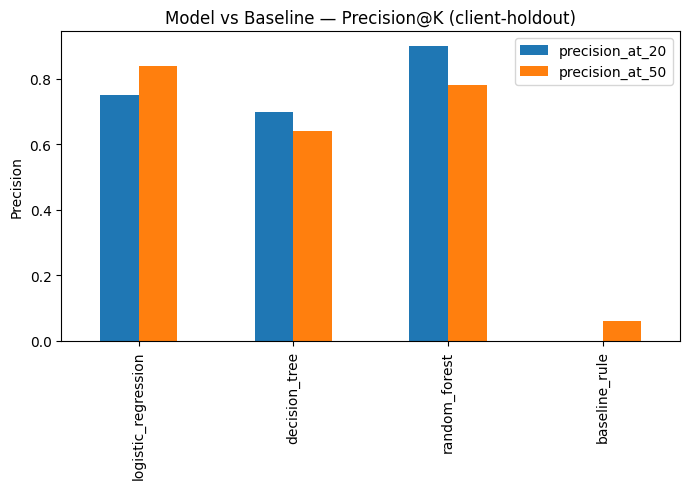

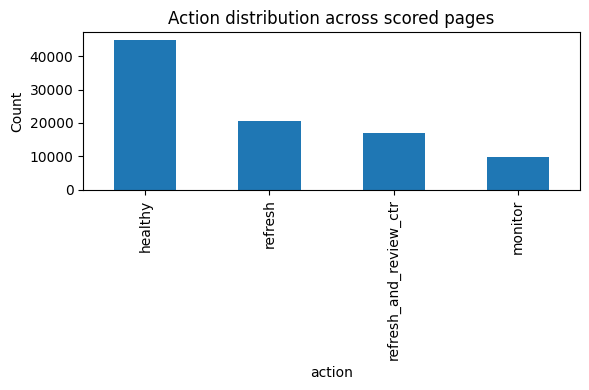

Artifacts saved: work/figures/model_comparison.png, work/figures/action_distribution.png, work/outputs/capstone_metrics.json


In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt
import json

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Chart 1: model comparison bar chart
comparison[["precision_at_20","precision_at_50"]].plot(kind="bar", figsize=(7,5))
plt.title("Model vs Baseline — Precision@K (client-holdout)")
plt.ylabel("Precision")
plt.tight_layout()
plt.savefig("work/figures/model_comparison.png")
plt.show()

# Chart 2: action distribution
plt.figure(figsize=(6,4))
data["action"].value_counts().plot(kind="bar")
plt.title("Action distribution across scored pages")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png")
plt.show()

# Save queue CSV (excluded from git by design)
queue.to_csv("work/outputs/capstone_ranked_queue.csv", index=False)

# Save metrics JSON (this DOES get committed)
metrics = {
    "model_comparison": comparison.to_dict(),
    "feature_importance": importances.to_dict(),
    "declining_rate": float(data["label"].mean()),
    "total_pages_scored": int(len(data)),
    "action_counts": data["action"].value_counts().to_dict(),
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Artifacts saved: work/figures/model_comparison.png, work/figures/action_distribution.png, work/outputs/capstone_metrics.json")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.